# Classic Models

In [ ]:
# import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [2]:
# Load the merged LLM dataset
df = pd.read_csv('llm_data/llm-dataset/eli5_all_llm_answers_cleaned.csv')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Original dataset shape: (13269, 5)
Columns: ['q_id', 'question', 'chatgpt', 'deepseek', 'gemini']


,q_id,question,chatgpt,deepseek,gemini
0,5lchat,Why there was a 'leap second' added to the end...,"Okay, so imagine you have a big clock that hel...",Think of Earth like a spinning top that's slow...,Imagine we have a super-duper perfect clock th...
1,5lcr1h,Why is it that we calm down when we take a dee...,"When you take a deep breath, it's like giving ...","When you feel scared or upset, your body gets ...",You know how sometimes when you're super excit...
2,5lcsyf,Why does 1080p on a 4k TV look better than 108...,"Okay, imagine you have two different kinds of ...",Imagine your TV screen is made of tiny light s...,Imagine your TV screen is like a giant board m...
3,5ld008,"Why does lights make a ""blinking"" effect when ...","When you look at a light from far away, it can...",Think of light like a tiny wave traveling thro...,Imagine the air between you and the light is l...
4,5ld1ko,How are pop-up and generally annoying web ads ...,Pop-up ads and annoying web ads are like those...,Imagine you have a lemonade stand and you give...,"Imagine you have a really cool new toy, and yo..."


In [3]:
# Separate each LLM answer into its own instance with an author column
instances = []

# Iterate through each row
for idx, row in df.iterrows():
    q_id = row['q_id']
    question = row['question']
    
    # Create an instance for each LLM
    for llm in ['chatgpt', 'deepseek', 'gemini']:
        instances.append({
            'q_id': q_id,
            'question': question,
            'answer': row[llm],
            'author': llm
        })

# Create the new dataframe
df = pd.DataFrame(instances)

print(f"Transformed dataset shape: {df.shape}")

print(f"\nAuthor distribution:")
print(df['author'].value_counts())

Transformed dataset shape: (39807, 4)

Author distribution:
author
chatgpt     13269
deepseek    13269
gemini      13269
Name: count, dtype: int64


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words=None, 
    lowercase=True,
    ngram_range=(2, 3),  # unigrams + bigrams
    min_df=15,             # ignore very rare terms (appear in fewer than 15 documents)
    max_df=1.0,            #  do not ignore very common terms (can help differentiate authors)
    sublinear_tf=True     
)

tf_idf = vectorizer.fit_transform(df["answer"])
terms = vectorizer.get_feature_names_out()
print("TF-IDF shape:", tf_idf.shape)

TF-IDF shape: (39807, 60751)


Before training the model, we will perform an 80/20 train/test split

In [5]:
# 80/20 train/test split, stratified by author to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    tf_idf,
    df["author"],
    test_size=0.2,
    random_state=67,
    stratify=df["author"]
)

### Classic Model #1: Logistic Regression

Logistic regression is one of the supervised machine learning models used for this task, since this requires multiclass classification (ChatGPT, Gemini, DeepSeek)

              precision    recall  f1-score   support

     chatgpt     0.9584    0.9382    0.9482      2654
    deepseek     0.9336    0.9589    0.9461      2654
      gemini     0.9750    0.9691    0.9720      2654

    accuracy                         0.9554      7962
   macro avg     0.9557    0.9554    0.9554      7962
weighted avg     0.9557    0.9554    0.9554      7962



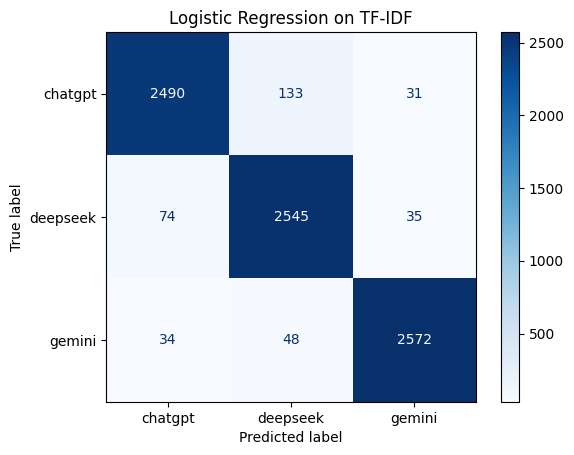

In [6]:
# train and fit
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["chatgpt", "deepseek", "gemini"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression on TF-IDF")
plt.show()

#### Hyperparameter Tuning

Hyperparameter tuning can be performed in logistic regression in the regularization constant C and the different regularization types: lasso and ridge.

In [ ]:
# define how the training and validation folds will be created for hyperparameter tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

In [ ]:
logreg_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"],
}

logreg_search = GridSearchCV(
    estimator=LogisticRegression(solver="saga", max_iter=4000),
    param_grid=logreg_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

logreg_search.fit(X_train, y_train)
best_logreg = logreg_search.best_estimator_
y_pred_logreg_tuned = best_logreg.predict(X_test)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Logistic Regression params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2'}
Best CV macro-F1: 0.9579

Tuned Logistic Regression on test split
              precision    recall  f1-score   support

     chatgpt     0.9659    0.9506    0.9582      2654
    deepseek     0.9456    0.9631    0.9543      2654
      gemini     0.9785    0.9759    0.9772      2654

    accuracy                         0.9632      7962
   macro avg     0.9633    0.9632    0.9632      7962
weighted avg     0.9633    0.9632    0.9632      7962



Show results

In [21]:
logreg_scores = pd.DataFrame(logreg_search.cv_results_)[
["rank_test_score", "mean_test_score", "std_test_score", "params"]
].sort_values("rank_test_score")

print("LogReg tuning results (macro-F1):")
display(logreg_scores)

LogReg tuning results (macro-F1):


,rank_test_score,mean_test_score,std_test_score,params
15,1,0.957892,0.002297,"{'C': 10, 'class_weight': 'balanced', 'penalty..."
13,2,0.957892,0.002265,"{'C': 10, 'class_weight': None, 'penalty': 'l2'}"
11,3,0.949580,0.001501,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
9,4,0.949485,0.001426,"{'C': 1, 'class_weight': None, 'penalty': 'l2'}"
14,5,0.940956,0.002077,"{'C': 10, 'class_weight': 'balanced', 'penalty..."
12,5,0.940956,0.002077,"{'C': 10, 'class_weight': None, 'penalty': 'l1'}"
7,7,0.923983,0.002726,"{'C': 0.1, 'class_weight': 'balanced', 'penalt..."
5,7,0.923983,0.002726,"{'C': 0.1, 'class_weight': None, 'penalty': 'l2'}"
10,9,0.915406,0.002093,"{'C': 1, 'class_weight': 'balanced', 'penalty'..."
8,9,0.915406,0.002093,"{'C': 1, 'class_weight': None, 'penalty': 'l1'}"


Best Logistic Regression params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2'}
Best CV macro-F1: 0.9579

Tuned Logistic Regression on test split
              precision    recall  f1-score   support

     chatgpt     0.9659    0.9506    0.9582      2654
    deepseek     0.9456    0.9631    0.9543      2654
      gemini     0.9785    0.9759    0.9772      2654

    accuracy                         0.9632      7962
   macro avg     0.9633    0.9632    0.9632      7962
weighted avg     0.9633    0.9632    0.9632      7962



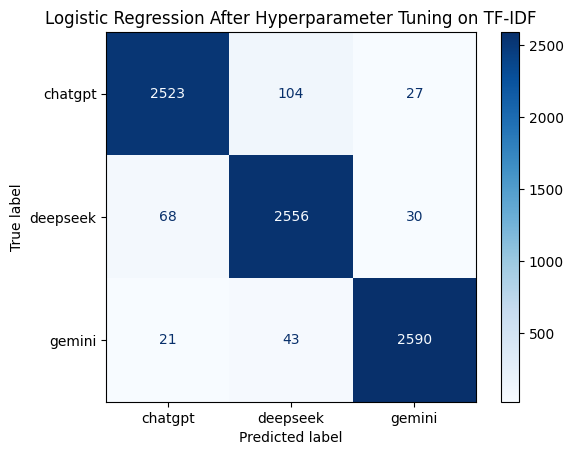

In [20]:
print("Best Logistic Regression params:", logreg_search.best_params_)
print("Best CV macro-F1:", round(logreg_search.best_score_, 4))
print("\nTuned Logistic Regression on test split")
print(classification_report(y_test, y_pred_logreg_tuned, digits=4))

cm = confusion_matrix(y_test, y_pred_logreg_tuned, labels=["chatgpt", "deepseek", "gemini"])

disp = ConfusionMatrixDisplay( 
    confusion_matrix=cm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression After Hyperparameter Tuning on TF-IDF")
plt.show()

#### Interpretation of results after hyperparameter tuning:

* C = 10: Less regularization lets the model focus more on important features that help tell models apart.
* L2 (Ridge) Regularization: Keeps the model from relying too much on a few features, so it generalizes better.
* Balanced Class Weights: Adjusts for uneven data so all classes are treated fairly, improving overall performance (macro-F1: 0.9579).

#### Classic Model 2: **Support Vector Machine (SVM)**

An SVM is a supervised machine learning models that classifies data by finding an optimal hyperplane or line that maximizes the distance between each class in an N-dimensional space [1].

SVM is optimized for high-dimensional text data. It also focuses on "confusing" responses at the boundaries to better identify between authors and ensure high classification accuracy.

In [8]:
# import SVM library
from sklearn.svm import SVC

A linear kernel can help avoid overfitting. Here, the features are linearly separable. Linearly separable is defined as being able to draw a straight boundary that seperates the different classes.

In [ ]:
# train and fit SVM with linear kernel
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_linear_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_linear_svm, digits=4))

# confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_linear_svm, labels=["chatgpt", "deepseek", "gemini"])

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp_svm.plot(cmap="Greens", values_format="d")
plt.title("SVM (Linear Kernel) on TF-IDF")
plt.show()

An Radial Basis Function (RBF) Kernel can capture non-linear relationships by projecting data into an infinite-dimensional space. It can draw curved boundaries around specific clusters that a straight line would miss.

In [ ]:
# train and fit SVM with rbf kernel
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_rbf_svm = svm.predict(X_test)

print(classification_report(y_test, y_pred_rbf_svm, digits=4))

# confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_rbf_svm, labels=["chatgpt", "deepseek", "gemini"])

disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp_svm.plot(cmap="Greens", values_format="d")
plt.title("SVM (RBF Kernel) on TF-IDF")
plt.show()

In [ ]:
print("Linear Kernel Results")
print(classification_report(y_test, y_pred_linear_svm, digits=4))
print("RBF Kernel Results")
print(classification_report(y_test, y_pred_rbf_svm, digits=4))

#### Interpretation:

* The linear kernel had a slightly higher accuracy (95.77%), compared to the RBF (95.52%). The linear kernel's performance indicates that LLM stylistic signatures are linearly separable in high-dimensional space. This makes complex, non-linear transformations unnecessary for optimal classification.

#### Hyperparameter Tuning: Linear Support Vector Machine (SVM)

Hyperparameter tuning will only be applied to the linear kernel since default values earlier showed that the LLM stylistic signatures are linearly separable (higher scores for linear kernel).

In [14]:
svm_param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10]},
]

svm_search = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

svm_search.fit(X_train, y_train)
best_svm = svm_search.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


Show results

In [18]:
# show all SVM macro-F1 CV scores for each hyperparameter combination
svm_results_df = pd.DataFrame(svm_search.cv_results_)
fold_cols = [c for c in svm_results_df.columns if c.startswith("split") and c.endswith("_test_score")]

svm_scores = svm_results_df[["rank_test_score", "mean_test_score", "std_test_score", "params"] + fold_cols]
svm_scores = svm_scores.sort_values("rank_test_score").reset_index(drop=True)

print("All SVM hyperparameter tuning scores (macro-F1):")
display(svm_scores)

All SVM hyperparameter tuning scores (macro-F1):


,rank_test_score,mean_test_score,std_test_score,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score
0,1,0.957813,0.001808,"{'C': 1, 'kernel': 'linear'}",0.958722,0.957527,0.954979,0.957340,0.960494
1,2,0.957147,0.002848,"{'C': 10, 'kernel': 'linear'}",0.954953,0.957981,0.956400,0.954183,0.962217
2,3,0.932740,0.001795,"{'C': 0.1, 'kernel': 'linear'}",0.931756,0.935500,0.930889,0.931348,0.934208


Best SVM params: {'C': 1, 'kernel': 'linear'}
Best CV macro-F1: 0.9578

Tuned SVM on test split
              precision    recall  f1-score   support

     chatgpt     0.9558    0.9544    0.9551      2654
    deepseek     0.9467    0.9578    0.9522      2654
      gemini     0.9848    0.9748    0.9797      2654

    accuracy                         0.9623      7962
   macro avg     0.9625    0.9623    0.9624      7962
weighted avg     0.9625    0.9623    0.9624      7962



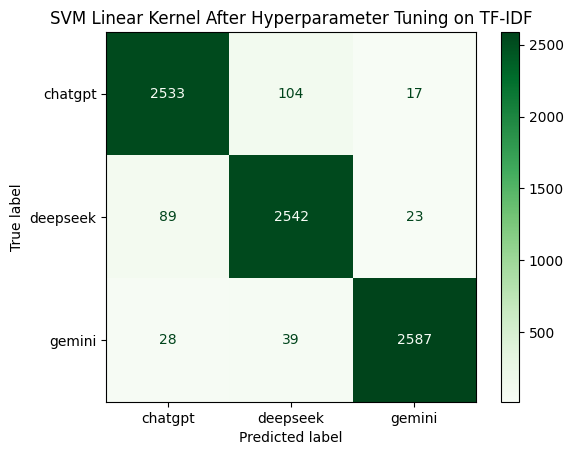

In [19]:
print("Best SVM params:", svm_search.best_params_)
print("Best CV macro-F1:", round(svm_search.best_score_, 4))
print("\nTuned SVM on test split")
print(classification_report(y_test, y_pred_svm_tuned, digits=4))

cm = confusion_matrix(y_test, y_pred_svm_tuned, labels=["chatgpt", "deepseek", "gemini"])

disp = ConfusionMatrixDisplay( 
    confusion_matrix=cm,
    display_labels=["chatgpt", "deepseek", "gemini"]
)
disp.plot(cmap="Greens", values_format="d")
plt.title("SVM Linear Kernel After Hyperparameter Tuning on TF-IDF")
plt.show()

Among the tested models, the **logistic regression with tuned hyperparameters** had the highest scores, with a 96.32% f1-score on the test split.

It can also be observed that the models performed the best on identifying text generated by Gemini, indicating that it possibly has the most unique fingerprint among the 3.

#### **References**

[1] Kavlakoglu, E. (2023, December 12). Support Vector Machine. Ibm.com. https://www.ibm.com/think/topics/support-vector-machine